In [1]:
import numpy as np
from astropy.io import fits
from astropy.table import Table, vstack
import matplotlib.pyplot as plt
import matplotlib as mpl
import h5py

mpl.rcParams['font.family'] = 'serif'
mpl.rcParams['axes.linewidth'] = 1.5
mpl.rcParams['axes.xmargin'] = 1
mpl.rcParams['xtick.labelsize'] = 'x-large'
mpl.rcParams['xtick.major.size'] = 5
mpl.rcParams['xtick.major.width'] = 1.5
mpl.rcParams['ytick.labelsize'] = 'x-large'
mpl.rcParams['ytick.major.size'] = 5
mpl.rcParams['ytick.major.width'] = 1.5
mpl.rcParams['legend.frameon'] = False


def sdss_rgb(imgs, bands=["g","r","z"], scales=dict(g=(2,6.0), r=(1,3.4), z=(0,2.2)),m = 0.03):
    rgbscales = {'u': (2,1.5), #1.0,
                 'g': (2,2.5),
                 'r': (1,1.5),
                 'i': (0,1.0),
                 'z': (0,0.4), #0.3
                 }
    
    if scales is not None:
        rgbscales.update(scales)

    I = 0
    for img,band in zip(imgs, bands):
        plane,scale = rgbscales[band]
        img = np.maximum(0, img * scale + m)
        I = I + img
    I /= len(bands)
        
    # b,g,r = [rimg * rgbscales[b] for rimg,b in zip(imgs, bands)]
    # r = np.maximum(0, r + m)
    # g = np.maximum(0, g + m)
    # b = np.maximum(0, b + m)
    # I = (r+g+b)/3.
    Q = 20
    fI = np.arcsinh(Q * I) / np.sqrt(Q)
    I += (I == 0.) * 1e-6
    H,W = I.shape
    rgb = np.zeros((H,W,3), np.float32)
    for img,band in zip(imgs, bands):
        plane,scale = rgbscales[band]
        rgb[:,:,plane] = (img * scale + m) * fI / I

    # R = fI * r / I
    # G = fI * g / I
    # B = fI * b / I
    # # maxrgb = reduce(np.maximum, [R,G,B])
    # # J = (maxrgb > 1.)
    # # R[J] = R[J]/maxrgb[J]
    # # G[J] = G[J]/maxrgb[J]
    # # B[J] = B[J]/maxrgb[J]
    # rgb = np.dstack((R,G,B))
    rgb = np.clip(rgb, 0, 1)
    
    return rgb





In [2]:
##below are some helper functions to download individual cutouts
import requests

session = requests.Session()

def save_cutouts(ra,dec,img_path,session, size=350, timeout = 120):
    '''
    Function to save image cutouts as fits file, contains WCS info.
    The invvar and maskbits flags can be removed in case the inverse variance and maskbits image are not needed
    '''
    url_prefix = 'https://www.legacysurvey.org/viewer-dev/'
    
    url = url_prefix + f'cutout.fits?ra={ra}&dec={dec}&size=%s&'%size

    url += 'layer=ls-dr9&pixscale=0.262&bands=grz&invvar&maskbits'

    try:
        resp = session.get(url, timeout=timeout)
        resp.raise_for_status()  # Raise error for bad status codes
        # Save the FITS file
        with open(img_path, "wb") as f:
            f.write(resp.content)
    
        #load the wcs and image data
        # img_data = fits.open(img_path)
        # data_arr = img_data[0].data
        # wcs = WCS(fits.getheader( img_path ))
    except:
        print("getting coadd image data failed!")
        print(url)
    
    return


def save_jpg(ra,dec,img_path,session, size=350):
    '''
    Function to download jpg image
    '''
    url_prefix = 'https://www.legacysurvey.org/viewer/'
    
    url = url_prefix + f'cutout.jpg?ra={ra}&dec={dec}&size=%s&'%size

    url += 'layer=ls-dr9&pixscale=0.262&bands=grz'
        
    resp = session.get(url)
    # Save the file
    with open(img_path, "wb") as f:
        f.write(resp.content)        

    return
    


In [3]:
h5_path = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/ssl_shred_data/desi_dr1_dwarf_catalog_images.h5"


In [11]:
# rng = np.random.default_rng(420)

n_show = 10

imgs_sel = []
tgids_sel = []

with h5py.File(h5_path, "r") as f:
    images = f["images"]
    targetids = f["targetid"]

    idxs = np.random.choice(100, size=n_show, replace=False)
    
    for i in idxs:
        imgs_sel.append(images[i])
        tgids_sel.append(targetids[i])

imgs_sel = np.stack(imgs_sel)
tgids_sel = np.array(tgids_sel)


In [12]:
print(tgids_sel)

[39627514225625637 39627509519617833 39627513802003678 39627514213042404
 39627509171488094 39627514208846335 39627514066239763 39627513936218839
 39627514036880787 39627509360237558]


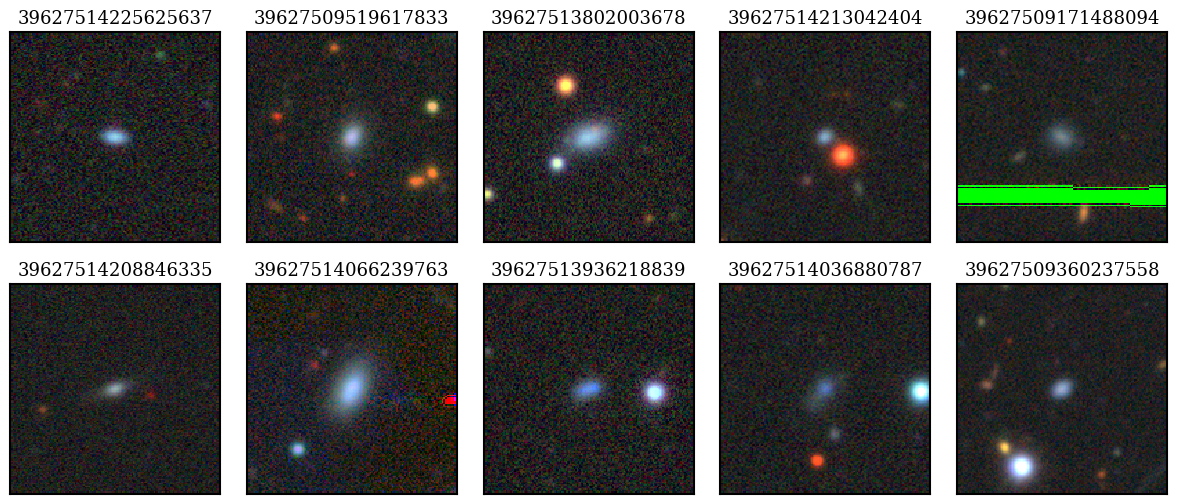

In [17]:
fig,ax = plt.subplots(2,5,figsize = (15,6))

plt.subplots_adjust(wspace=0.1)

all_axs = np.concatenate(ax)

for i in range(len(tgids_sel)):
    all_axs[i].set_title(f"{tgids_sel[i]}",fontsize = 13)
    rgb_i = sdss_rgb(imgs_sel[i])
    all_axs[i].imshow(rgb_i, origin="lower",interpolation="None")

for axii in all_axs: 
    axii.set_xticks([])
    axii.set_yticks([])
    axii.set_aspect("equal")
plt.show()